# Unmixing coercivity spectra from backfield curves

## Background on coercivity spectra

Natural samples contain ferromagnetic materials dispersed in paramagnetic and/or diamagnetic matrix material. Ferromagnetic mineral assemblages can be composed of minerals with different compositions, shapes, and sizes, such that they have different coercivities. Coercivity refers to the resistance of a ferromagnetic material to becoming demagnetized in the presence of an applied field. It is common in the fields of rock and environmental magnetism to use backfield magnetic remanence curves to gain insight into coercivity and thereby the ferromagnetic mineral assemblage within samples. Alternatively, a similar analysis can be conducted on isothermal remanent magnetization (IRM) acquisition or alternating field (AF) demagnetization data.

A backfield experiment is typically conducted on a vibrating sample magnetometer (VSM). In such an experiment, a strong external field is applied to the sample in one direction to induce a saturation isothermal remanent magnetization (sIRM), followed by the application of a field in the opposite direction. The process is repeated with the sIRM being applied, followed by reverse fields that are progressively larger in each step of the experiment. The derivative of the resultant backfield curve is referred to as the coercivity spectrum. A common data analysis workflow is to fit components of this spectrum to 'unmix' different populations of magnetic minerals.

Programs developed for this analysis include MAX UnMix (Maxbauer et al., 2016), IRM UnMix (Heslop et al., 2002), GECA (Egli, 2003), and IRM-CLG (Kruiver et al., 2001). This notebook documents the unmixing framework implemented in `rockmagpy`, which includes an implementation of the MAX UnMix workflow alongside a complementary direct curve-fitting approach.

## The component model

Robertson and France (1994) made the observation that the coercivity distribution of a single population of magnetic grains can often be closely approximated by a Gaussian distribution in $\log_{10}(B)$ space (a log-Gaussian). Egli (2003) and subsequent work showed that natural components can deviate from perfect log-normality, motivating skewed generalizations.

In `rockmagpy`, every unmixing component is a skew-normal distribution in $x = \log_{10}(B/\mathrm{mT})$ described by four parameters:

- `contribution` — the integrated area of the component in the units of the magnetization data (its share of the total remanence);
- `location` — the location parameter $\xi$ (equal to the mean only for symmetric components);
- `dp` — the scale parameter $\omega$ in $\log_{10}$ units (equal to the standard deviation only for symmetric components);
- `skew` — the Azzalini shape parameter $\alpha$ (0 = symmetric log-Gaussian; negative values skew the distribution toward low coercivities).

Because the skew-normal has an analytic cumulative distribution function (via Owen's T function), the *same* component model can be fit in two different data spaces, and all methods are accessed through a common entry point, `rmag.unmix_coercivity(x, M, method=...)`:

1. **spectrum space** (`method='spectrum'`) — fitting the derivative $\mathrm{d}M/\mathrm{d}\log_{10}(B)$, the approach popularized by Kruiver et al. (2001), Egli (2003), and MAX UnMix (Maxbauer et al., 2016). This operates in the space where components are visually interpreted, but requires numerically differentiating (and typically smoothing) the measurements.
2. **measurement space** (`method='curve'`) — fitting the measured remanence curve $M(B)$ directly with cumulative components, which avoids differentiation and smoothing altogether and works with the original noise structure of the data.
3. **MAX UnMix emulation** (`method='maxunmix'`) — the spectrum-space fit combined with the MAX UnMix resampling uncertainty scheme of Maxbauer et al. (2016). Two implementation details differ from the R original: skewness follows the Azzalini parameterization rather than the Fernandez–Steel one, and component amplitudes are parameterized by integrated area rather than peak height, which maps directly onto the fraction of remanence carried by each component.
4. **Bayesian posterior sampling** (`method='bayes'`) — nested sampling of the full posterior in measurement space (requires the optional `dynesty` package), which represents parameter trade-offs between overlapping components and returns the Bayesian evidence for choosing the number of components. This method, together with multi-start mapping of alternative solutions and the mineral-prior library, is documented extensively in the companion notebook [`coercivity_unmixing_bayesian.ipynb`](./coercivity_unmixing_bayesian.ipynb).

Because the parameterization is shared, results from the different methods are directly comparable, and agreement between the two fitting spaces is a good indication of a robust unmixing model. Derived quantities reported for every component include the mean coercivity `B_mean_mT`, the median and peak coercivities, the distribution standard deviation `sd_log` (the dispersion parameter DP of the literature), and the `proportion` of the total remanence. The method registry is user-extensible (`rmag.register_unmixing_method`; see the companion notebook).

## Import scientific python libraries

Run the cell below to import the functions needed for the notebook.

In [1]:
import pmagpy.rockmag as rmag
import pmagpy.ipmag as ipmag
import pmagpy.contribution_builder as cb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## MaxUnmix example

We start with the example data file that was published with MaxUnmix. `rmag.process_backfield_data` shifts the magnetization positive and converts the field values to $\log_{10}$(mT). A light smoothing (`smooth_frac=0.075`) is applied here for display of the spectrum; the degree of smoothing is a choice the user should test, since over-smoothing biases component widths (Maxbauer et al., 2016).

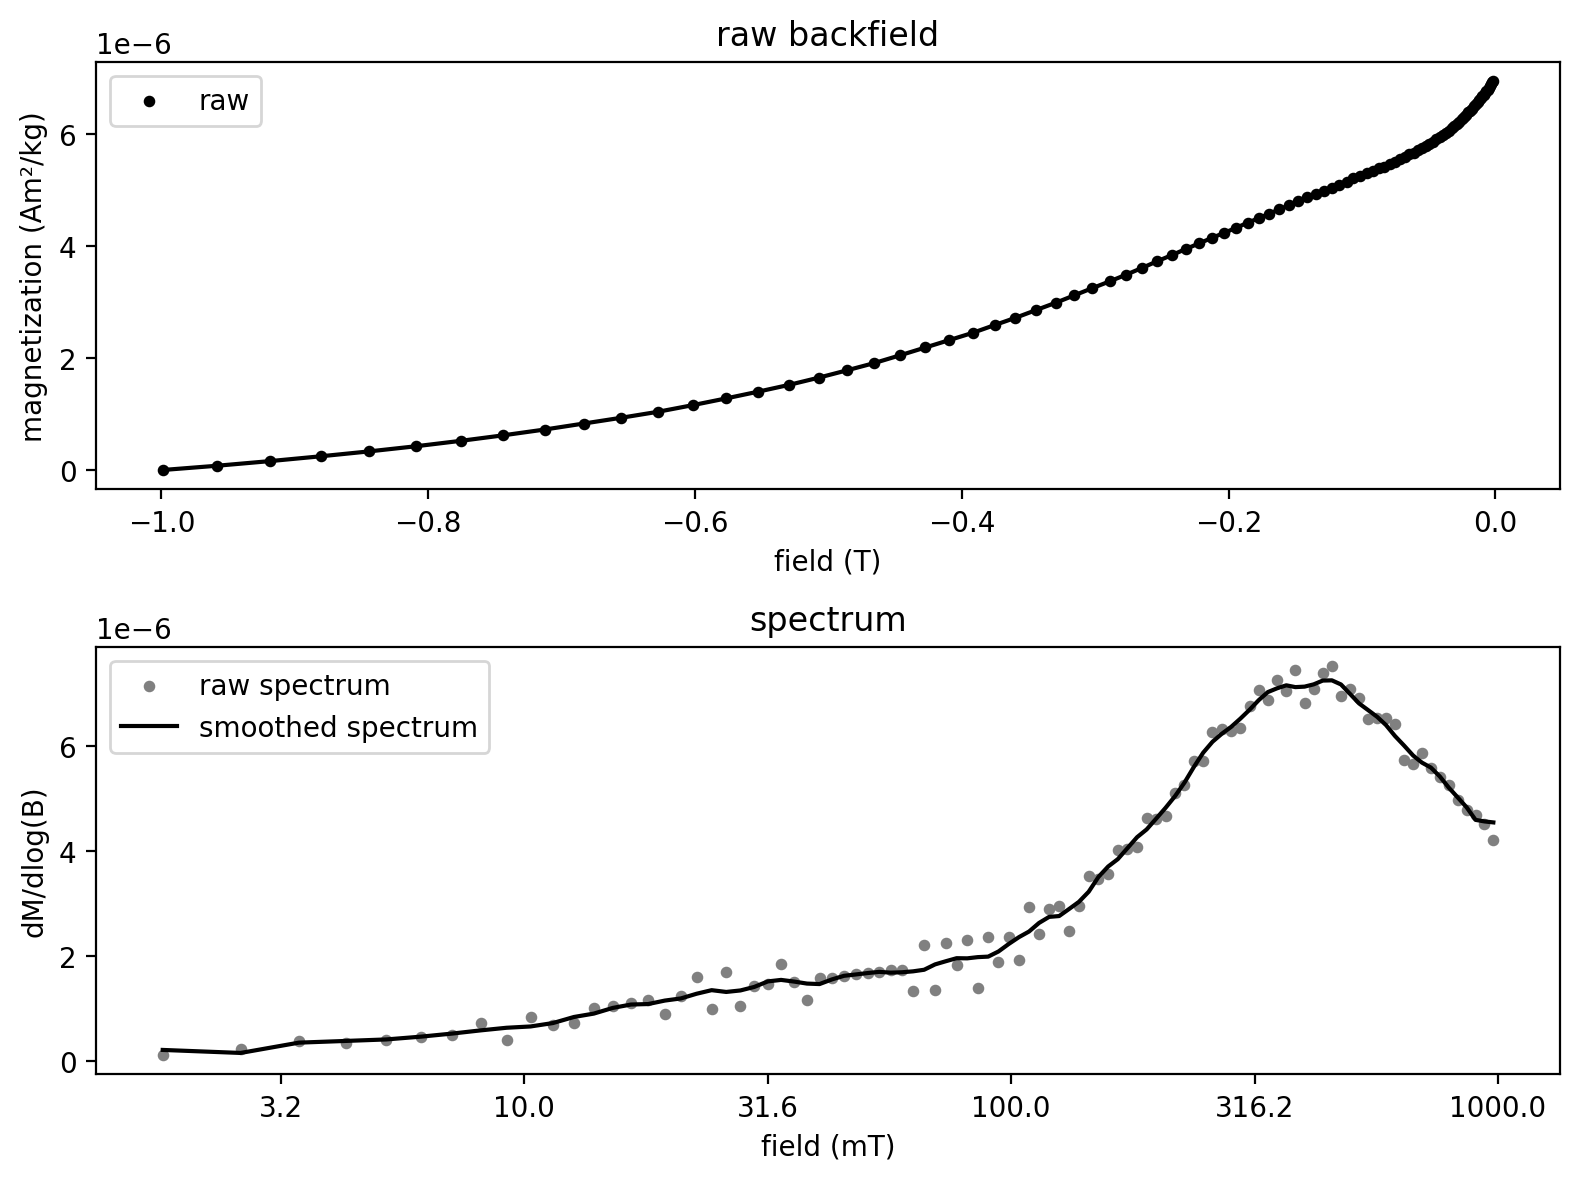

In [2]:
MaxUnmix_data = pd.read_csv('../example_data/backfield_unmixing/MaxUnmix_example.csv')
MaxUnmix_data['B'] = -MaxUnmix_data['B']/1000
MaxUnmix_experiment, MaxUnmix_Bcr = rmag.process_backfield_data(MaxUnmix_data,
                                                                   field='B',
                                                                   magnetization='M',
                                                                   smooth_frac=0.075)
fig, axs = rmag.plot_backfield_data(MaxUnmix_experiment,
                                    field='B', magnetization='M', figsize=(8, 6),
                                    plot_processed=False, plot_spectrum=True,
                                    return_figure=True)

### Interactive choice of initial parameters

An important aspect of the MaxUnmix process is for the user to make an initial guess for the parameters associated with the coercivity spectra that can then be optimized to fit the spectra. Initial choices matter, because coercivity unmixing is a non-convex problem in which differently seeded fits can converge to different solutions (demonstrated explicitly near the end of this notebook).

`rmag.coercivity_unmixing_interactive` provides sliders for each component's peak field (mT, on a log scale), proportion of the total remanence, dispersion (DP, in $\log_{10}$ units), and (optionally) skew. The sliders are seeded by automatic peak detection, and the live curves show the model implied by the current slider values. Pressing **Fit from these values** runs the optimizer starting from the slider settings and overlays the result.

*For live figure updates run `%matplotlib widget` first (requires the `ipympl` package); with the inline backend the widget still works but the figure only refreshes when a cell is re-run.*

The returned handle is a dictionary whose `'initial_parameters'` entry always reflects the current slider values and whose `'result'` entry is filled once Fit has been pressed.

Button(button_style='primary', description='Fit from these values', style=ButtonStyle())

Output()

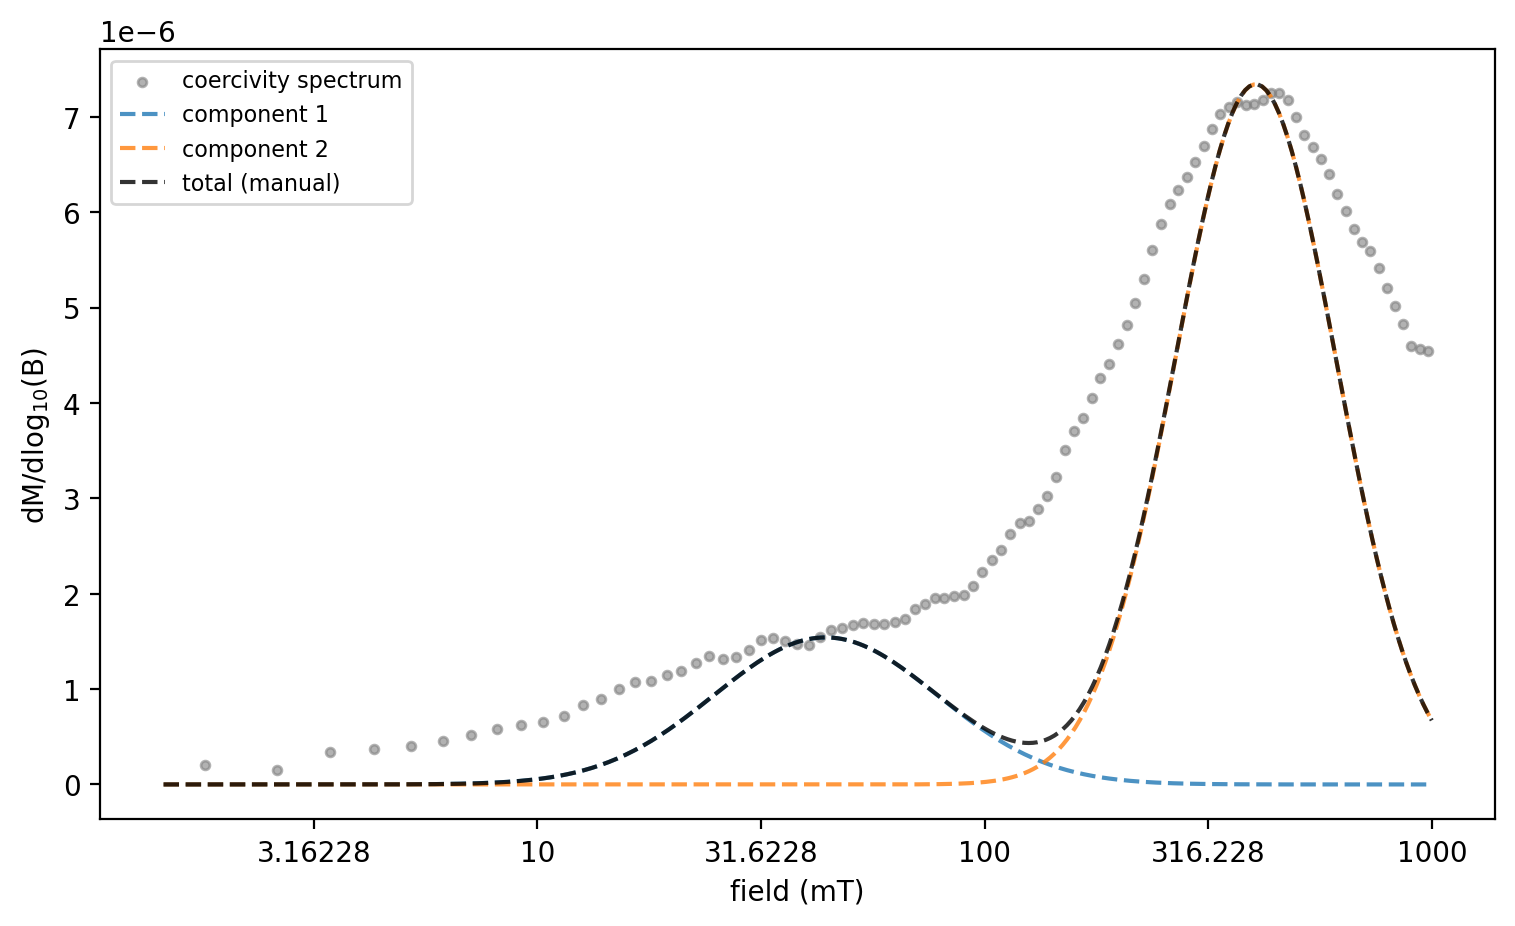

In [3]:
# %matplotlib widget  # uncomment for live slider updates (requires ipympl)
x_mu = MaxUnmix_experiment['smoothed_log_dc_field'].to_numpy()
M_mu = MaxUnmix_experiment['smoothed_magn_mass_shift'].to_numpy()
handle = rmag.coercivity_unmixing_interactive(x_mu, M_mu, n_components=2,
                                              method='spectrum',
                                              vary_skew=False)

In [4]:
handle['initial_parameters'].round(4)

,contribution,location,dp,skew
0,0.0,1.6445,0.25,0.0
1,0.0,2.6059,0.18,0.0


### MaxUnMix fit with resampling uncertainties

`method='maxunmix'` fits the spectrum from the chosen initial parameters and then applies the MAX UnMix resampling scheme, faithfully reproducing the Maxbauer et al. (2016) workflow: each replicate recomputes the spectrum from a random 95% subset of the magnetization points (drawn without replacement) and refits it, restarting from the best-fit parameters perturbed by 2% Gaussian noise; parameter means, standard deviations, and 95% percentile intervals over the converged replicates are reported, and the fit plot shows the corresponding uncertainty bands.

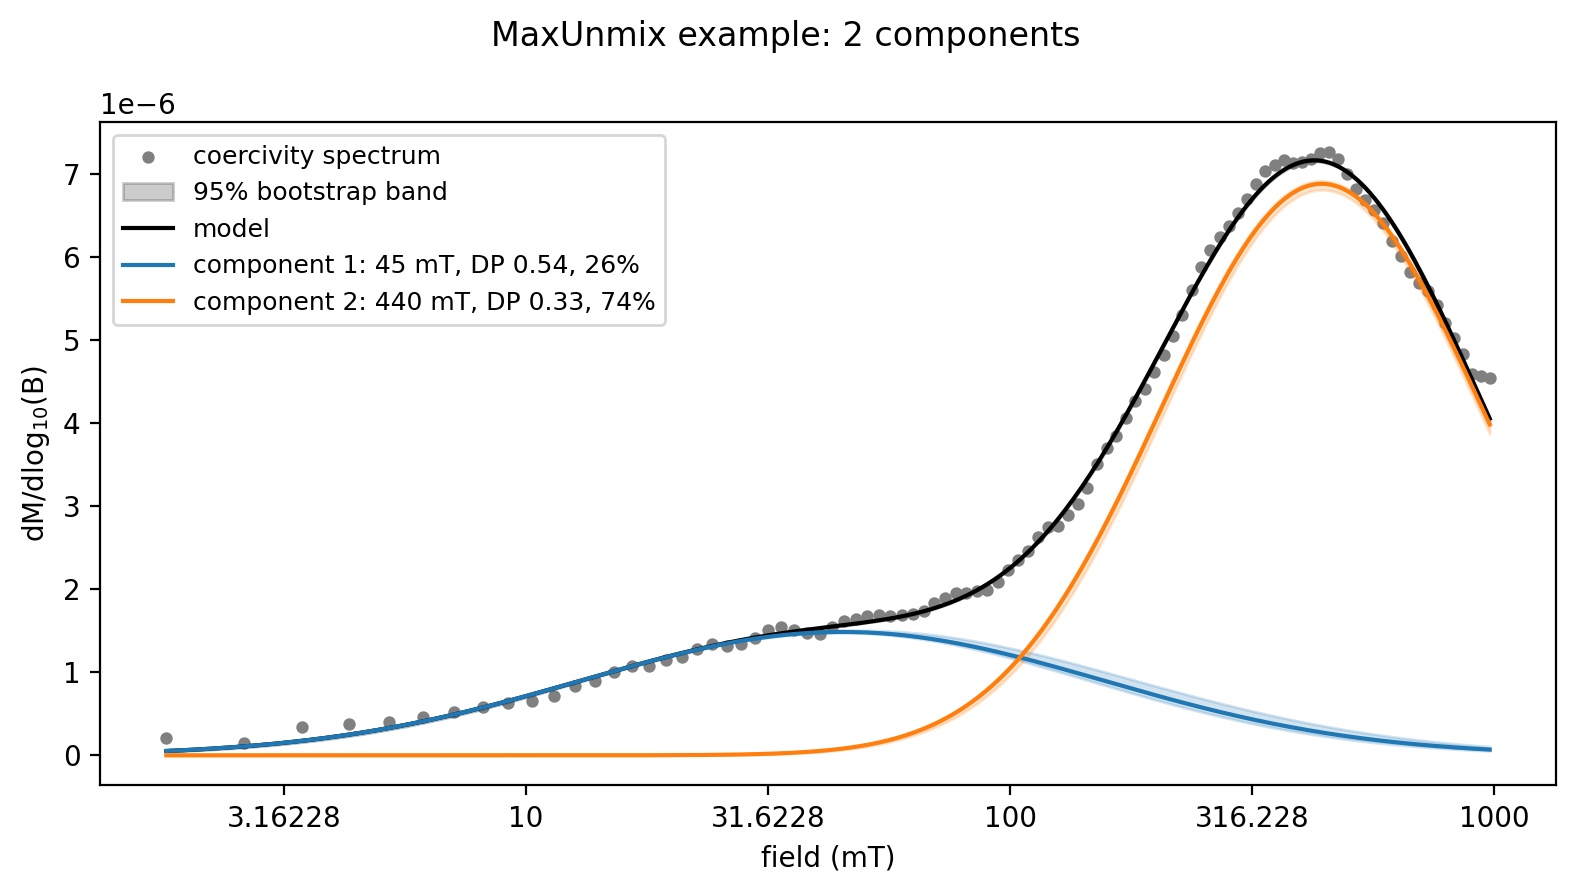

In [5]:
maxunmix_result = rmag.unmix_coercivity(x_mu, M_mu, method='maxunmix',
                                        initial_parameters=handle['initial_parameters'],
                                        vary_skew=False,
                                        n_boot=200, random_seed=1)
fig, axes = rmag.plot_coercivity_unmixing(maxunmix_result,
                                          title='MaxUnmix example: 2 components')

In [6]:
maxunmix_result['bootstrap']['param_summary'][[
    'B_mean_mT_mean', 'B_mean_mT_std', 'B_mean_mT_p2_5', 'B_mean_mT_p97_5',
    'sd_log_mean', 'sd_log_std',
    'proportion_mean', 'proportion_std']].round(3)

,B_mean_mT_mean,B_mean_mT_std,B_mean_mT_p2_5,B_mean_mT_p97_5,sd_log_mean,sd_log_std,proportion_mean,proportion_std
component,,,,,,,,
1,45.109,1.170,43.646,48.655,0.540,0.009,0.26,0.006
2,440.162,0.726,438.761,441.404,0.332,0.002,0.74,0.006


## Case study: red bed backfield data in MagIC format

The rest of this notebook works with backfield curves from hematite-bearing siltstone intraclasts of the ~1 Ga Freda Formation (Bad River, Wisconsin) that were studied in:

> Swanson-Hysell, N. L., Fairchild, L. M., & Slotznick, S. P. (2019). Primary and secondary red bed magnetization constrained by fluvial intraclasts. *Journal of Geophysical Research: Solid Earth*, 124. https://doi.org/10.1029/2018JB017067

These specimens contain a narrow high-coercivity detrital hematite component and a broader lower-coercivity pigmentary hematite component, making them a nice unmixing test case. A subset of the study's MagIC-format rock magnetic data is included in the `example_data` folder of this repository (the full contribution can be downloaded from MagIC with `ipmag.download_magic_from_id`). We load the contribution and filter the measurements for experiments with the `LP-BCR-BF` method code (lab protocol - backfield coercivity remanence - backfield); columns `magn_mass` and `treat_dc_field` contain the mass-normalized magnetization and the applied back field respectively.

In [7]:
dir_path = '../example_data/backfield_unmixing/redbed_MagIC'
contribution = cb.Contribution(dir_path)
measurements = contribution.tables['measurements'].df.dropna(axis=1, how='all')
specimens = contribution.tables['specimens'].df

backfield_measurements = measurements[measurements.method_codes == 'LP-BCR-BF']
backfield_measurements['experiment'].unique()

-I- Using online data model


-I- Getting method codes from earthref.org


-I- Importing controlled vocabularies from https://earthref.org


<StringArray>
['IRM-VSM2-LP-BCR-BF-198106', 'IRM-VSM2-LP-BCR-BF-198107',
 'IRM-VSM2-LP-BCR-BF-198073', 'IRM-VSM2-LP-BCR-BF-198074',
 'IRM-VSM2-LP-BCR-BF-198193', 'IRM-VSM2-LP-BCR-BF-198199']
Length: 6, dtype: str

### Processing an example experiment

We process the backfield curve for specimen BRIC.22c. Here we leave the data unsmoothed (`smooth_frac=0`) — the fitting approaches below are designed to work with raw measurements, and smoothing choices are one of the subjective steps that unmixing results should not hinge on.

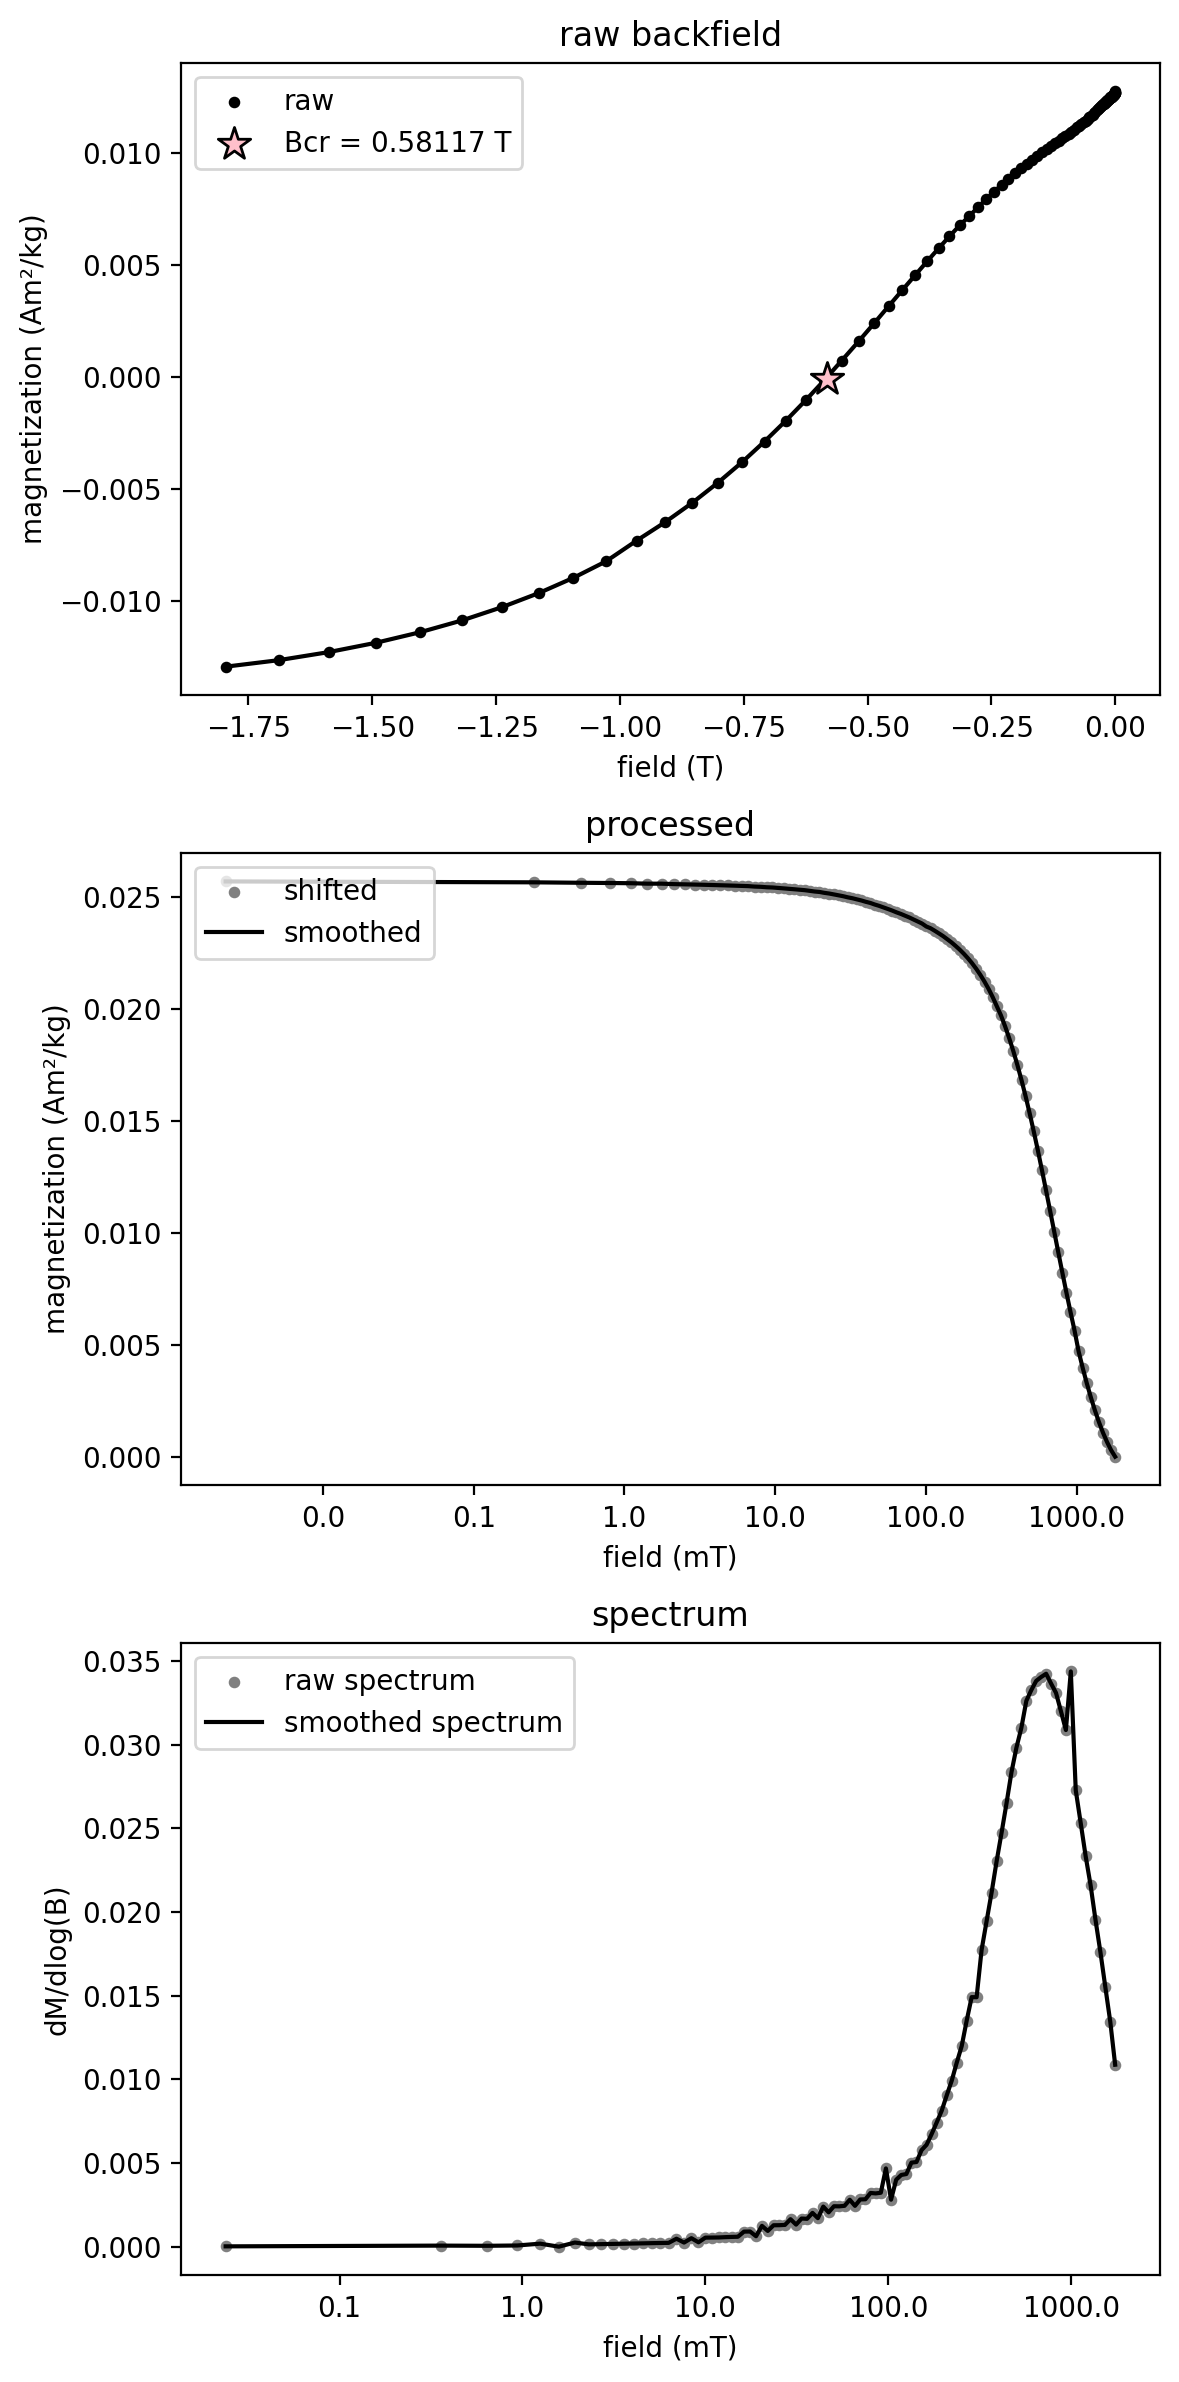

In [8]:
specimen_name = 'BRIC.22c'
experiment_name = 'IRM-VSM2-LP-BCR-BF-198193'

selected_experiment = backfield_measurements[
    backfield_measurements['experiment'] == experiment_name].reset_index(drop=True)
selected_experiment, Bcr = rmag.process_backfield_data(selected_experiment,
                                                          smooth_mode='spline',
                                                          smooth_frac=0.0)
fig, axes = rmag.plot_backfield_data(selected_experiment, Bcr=Bcr,
                                     figsize=(6, 12), return_figure=True)

### Unmixing the coercivity spectrum (`method='spectrum'`)

With a number of components specified (rather than an explicit initial-parameter table), initial guesses are estimated automatically by peak detection with `rmag.estimate_coercivity_components`. The fit is a bounded trust-region least squares (via `scipy.optimize.least_squares`). The returned dictionary contains the fitted parameter table (`'params'`, with linearized standard errors `se_*` and derived coercivities), the fitted curve, residuals, and fit statistics (RSS, $R^2$, AIC, BIC).

Here we fit two symmetric log-Gaussian components (`vary_skew=False`). While the library default is to allow skew (`vary_skew=True`), fixing the skew at zero is often a sensible starting point: skew is best varied only when there is a clear data-driven or mineralogical justification, since skewed components can trade off against one another.

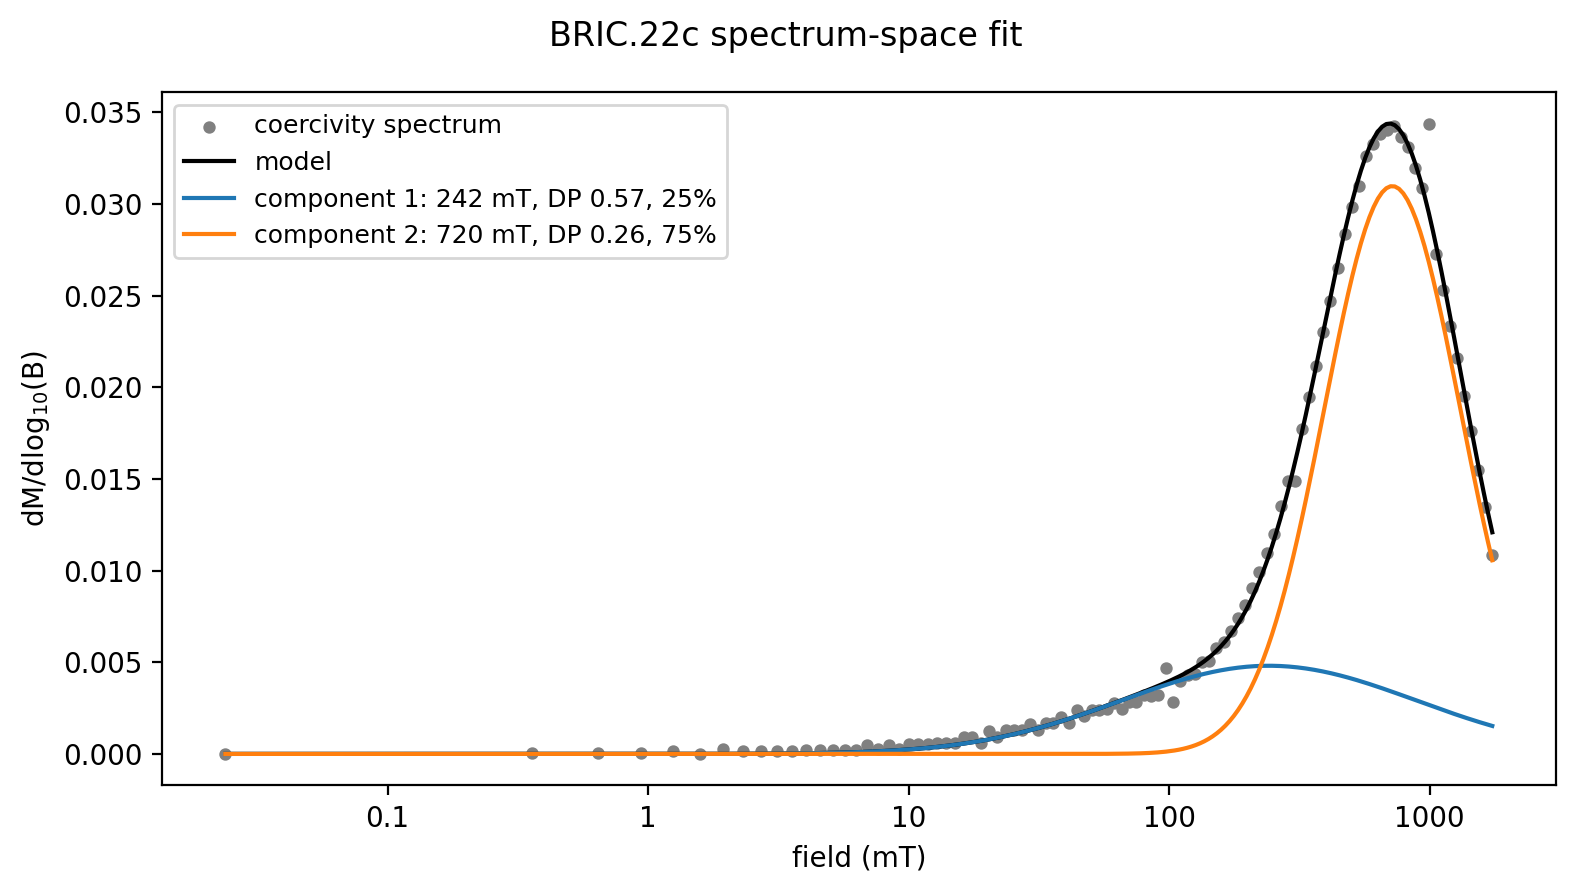

In [9]:
x = selected_experiment['log_dc_field'].to_numpy()
M = selected_experiment['magn_mass_shift'].to_numpy()

result_spectrum = rmag.unmix_coercivity(x, M, method='spectrum',
                                        n_components=2, vary_skew=False)
fig, axes = rmag.plot_coercivity_unmixing(result_spectrum,
                                          title=f'{specimen_name} spectrum-space fit')

In [10]:
result_spectrum['params'].round(4)

,contribution,proportion,se_contribution,location,se_location,dp,se_dp,skew,se_skew,sd_log,log10_B_mean,B_mean_mT,B_median_mT,B_peak_mT
component,,,,,,,,,,,,,,
1,0.0068,0.2514,0.0030,2.3836,0.2662,0.5659,0.1184,0.0,0.0,0.5659,2.3836,241.8634,241.8634,241.8634
2,0.0203,0.7486,0.0025,2.8572,0.0043,0.2616,0.0106,0.0,0.0,0.2616,2.8572,719.7565,719.7565,719.7565


### Fitting the measured curve directly (`method='curve'`)

Numerical differentiation amplifies measurement noise, and the degree of smoothing applied before differentiating can bias the widths and amplitudes of fitted components (Heslop et al., 2002; Maxbauer et al., 2016). The `'curve'` method sidesteps this by fitting the backfield curve itself with cumulative skew-normal components plus a constant offset — no derivative is ever taken. There is empirical and theoretical support for log-Gaussian coercivity components, and since the cumulative model is the exact integral of the spectral model, nothing is lost by fitting in measurement space; the parameters remain those of the log-Gaussian (or skew-normal) coercivity distributions.

Note that for a shifted backfield curve, which spans twice the saturation remanence, each fitted `contribution` is twice the remanence carried by that component; `proportion` values are unaffected.

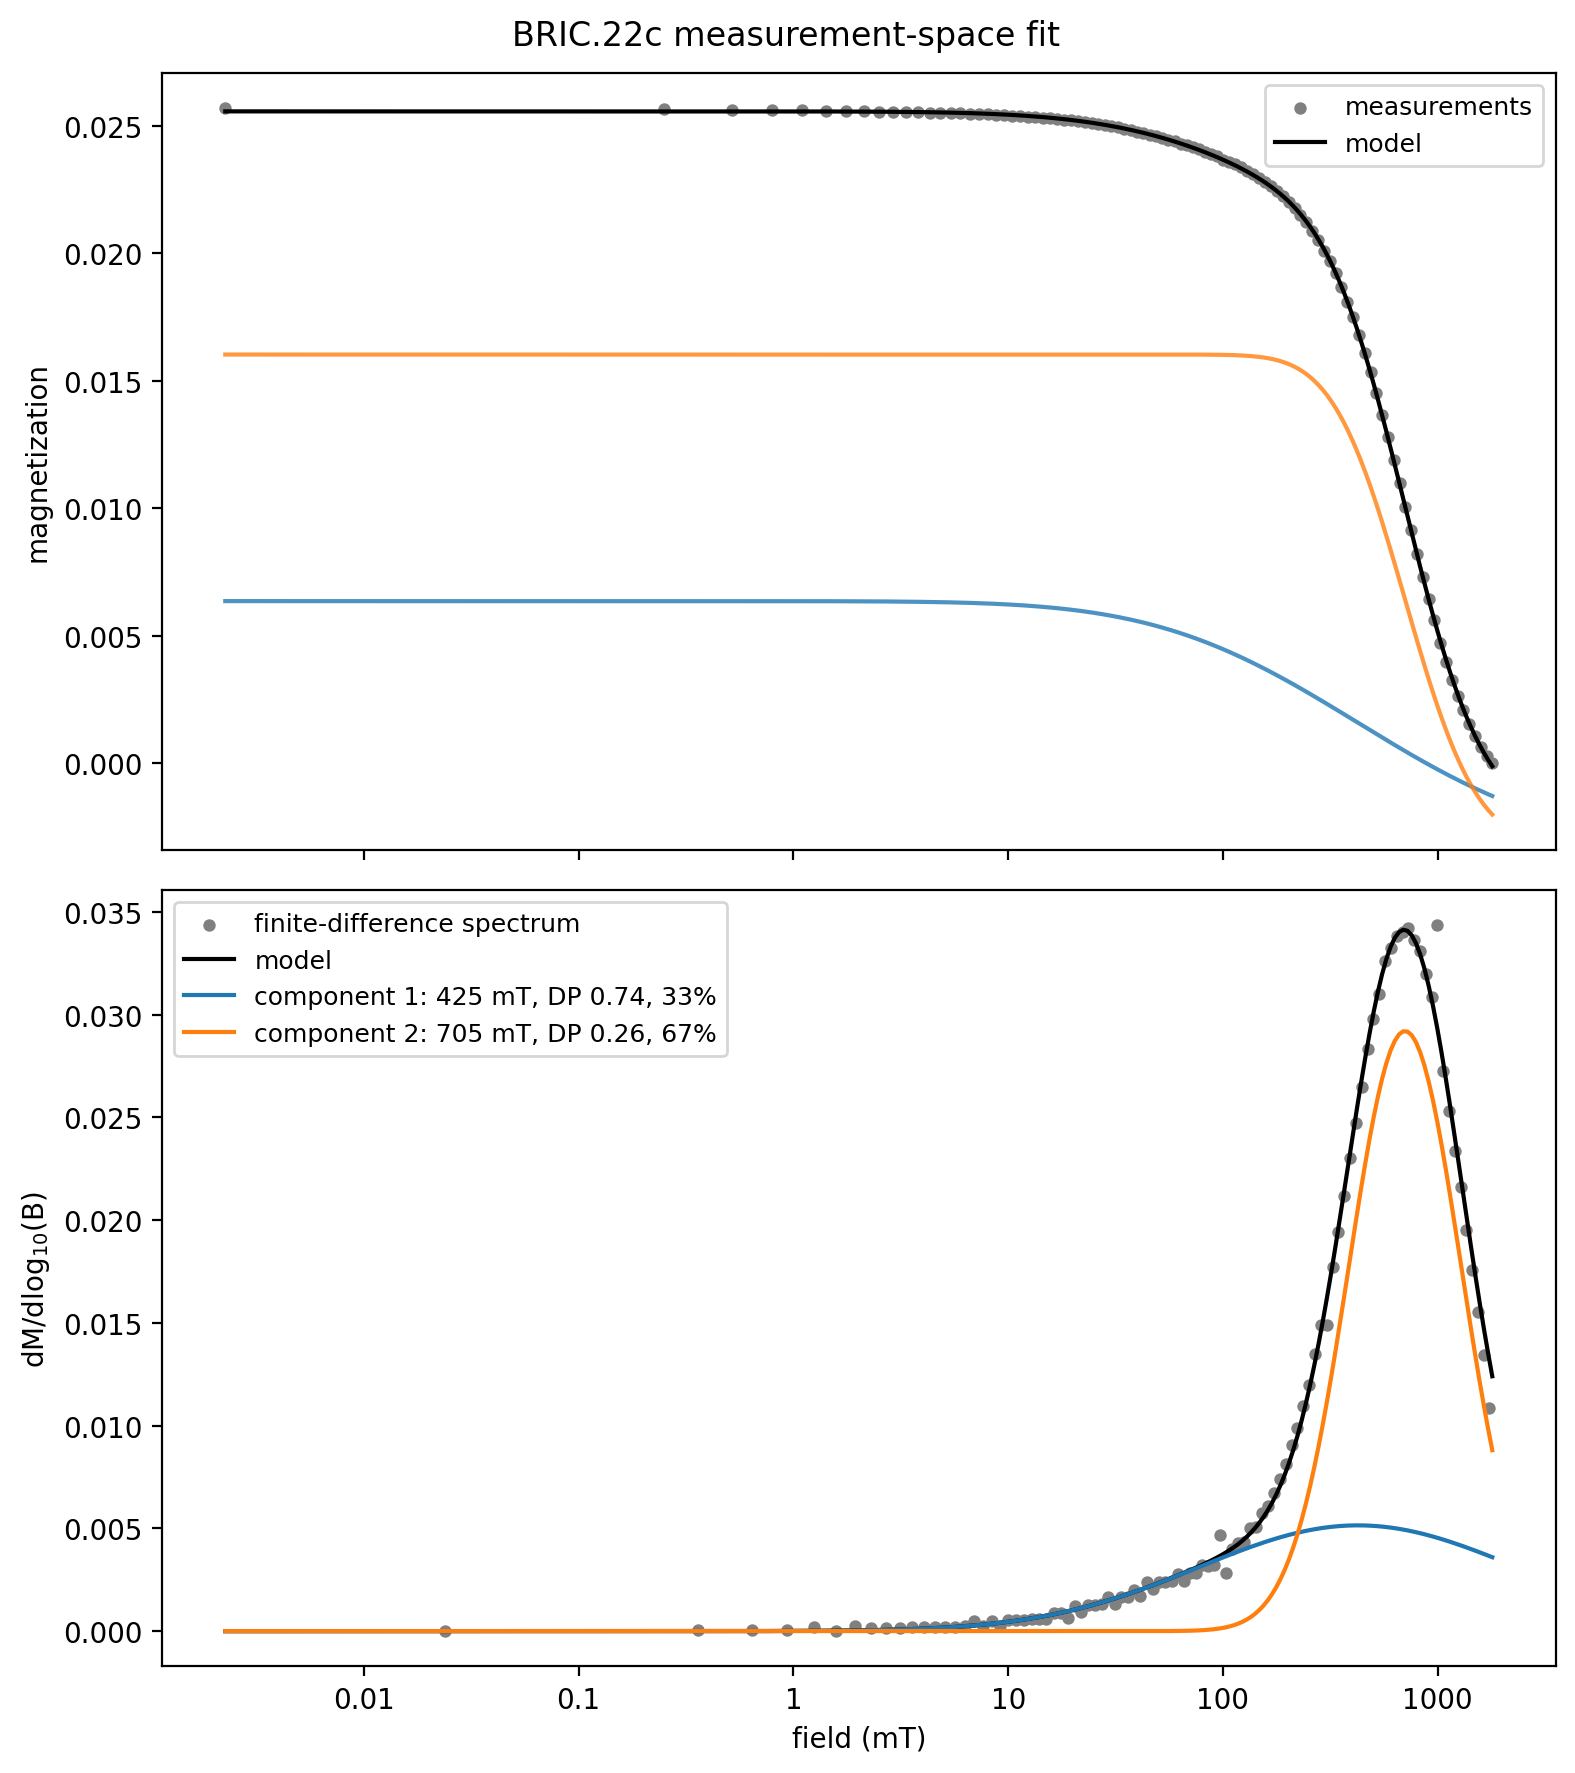

In [11]:
result_curve = rmag.unmix_coercivity(x, M, method='curve',
                                     n_components=2, vary_skew=False)
fig, axes = rmag.plot_coercivity_unmixing(result_curve,
                                          title=f'{specimen_name} measurement-space fit')

In [12]:
comparison = pd.DataFrame({
    'spectrum: B_mean (mT)': result_spectrum['params']['B_mean_mT'],
    'curve: B_mean (mT)': result_curve['params']['B_mean_mT'],
    'spectrum: DP': result_spectrum['params']['sd_log'],
    'curve: DP': result_curve['params']['sd_log'],
    'spectrum: proportion': result_spectrum['params']['proportion'],
    'curve: proportion': result_curve['params']['proportion'],
})
comparison.round(3)

,spectrum: B_mean (mT),curve: B_mean (mT),spectrum: DP,curve: DP,spectrum: proportion,curve: proportion
component,,,,,,
1,241.863,425.340,0.566,0.739,0.251,0.332
2,719.756,704.893,0.262,0.262,0.749,0.668


The two data spaces agree closely on the narrow, high-coercivity component (mean coercivity ~720 vs ~705 mT, essentially identical dispersion) but *not* on the broad, low-coercivity component: its mean coercivity differs substantially between the two fits (~242 mT in spectrum space vs ~425 mT in measurement space), along with its dispersion (DP ~0.57 vs ~0.74) and its share of the remanence (~25% vs ~33%). This is the first concrete instance of a theme that runs through the rest of this notebook and the companion Bayesian notebook: a broad, low-amplitude component is intrinsically poorly constrained, and two nearly equivalent fits can partition it quite differently. Agreement between the two data spaces is a useful robustness check precisely because *disagreement* flags which components are, and are not, well determined — here the narrow high-coercivity component is trustworthy while the broad low-coercivity one should be treated with caution.

## How many components?

The number of components is the most consequential modeling choice. `rmag.compare_unmixing_models` provides the standard statistical tools: information criteria (AIC/BIC, where lower is better) and sequential F-tests against the next-simpler model.

In [13]:
results_by_n = [rmag.unmix_coercivity(x, M, method='spectrum',
                                      n_components=n, vary_skew=False)
                for n in (1, 2, 3, 4)]
rmag.compare_unmixing_models(results_by_n).round(4)

,n_components,n_params,rss,r_squared,aic,bic,F,p_value,delta_aic,delta_bic
0,1,3,0.0002,0.9809,-1270.6910,-1262.9056,NaN,NaN,199.5731,184.0024
1,2,6,0.0000,0.9973,-1456.6964,-1441.1257,184.6025,0.0000,13.5676,5.7823
2,3,9,0.0000,0.9977,-1470.2640,-1446.9080,6.5562,0.0005,0.0000,0.0000
3,4,12,0.0000,0.9978,-1465.1101,-1433.9686,0.2489,0.8619,5.1540,12.9393


The second component produces an enormous improvement (large F, vanishing p-value, a large drop in AIC/BIC), unambiguously supporting two components over one. But notice that the criteria still improve for a *third* component — in this fit it is even the AIC/BIC minimum, and the F-test finds it significant (p ≈ 0.0005) — despite the two well-separated mineral populations already being captured. This is a general and important trap: with high-resolution, low-noise curves, AIC, BIC, F-tests, and the Bayesian evidence tend to keep rewarding extra components well beyond the mineralogically meaningful count, because a real coercivity distribution is never *exactly* log-Gaussian and each added component mops up a little more systematic misfit. (Here the *fourth* component is finally rejected — it worsens both AIC and BIC and the F-test is insignificant, p ≈ 0.86 — but on even lower-noise data the criteria would keep favoring more.) Left unchecked, these criteria would happily fit spurious components that subdivide a single mineral population.

The fix is an explicit **parsimony rule**: prefer the simplest model that is already *adequate*, rather than the one that minimizes a criterion (Egli, 2003; Heslop, 2015). `rmag.select_n_components` implements this. Its default 'parsimony' criterion retains an added component only if it reduces the residual by at least a set fraction (default 2%) of the baseline single-component misfit — so the second component (which removes ~99% of the misfit) is kept while a third (which removes only ~1%, below the 2% threshold) is rejected, regardless of how low the noise is.

In [14]:
n_selected, selection_table, _fits = rmag.select_n_components(
    x, M, method='curve', max_components=4, verbose=True)
selection_table[['n_components', 'r_squared', 'rss_improvement_fraction',
                 'reduced_chi2', 'selected']].round(4)

selected 2 component(s) by 'parsimony' criterion (noise ~ 3.48e-06)


,n_components,r_squared,rss_improvement_fraction,reduced_chi2,selected
0,1,0.9982,NaN,9574.7905,False
1,2,1.0000,0.9873,126.7172,True
2,3,1.0000,0.0112,15.4509,False
3,4,1.0000,0.0004,11.7514,False


The `rss_improvement_fraction` column makes the choice transparent: the second component explains the overwhelming majority of the baseline misfit, while the third and fourth explain almost none. The `reduced_chi2` column shows the complementary view — adding the second component collapses the reduced chi-square by roughly two orders of magnitude; the residuals that remain sit about an order of magnitude above the estimated measurement noise (a real spectrum is never exactly a sum of log-Gaussians), and further components chip away at that small systematic misfit rather than capture additional mineral populations. (For data with a trusted, independently measured noise level, `criterion='chi2'` selects the simplest model whose reduced chi-square reaches ~1 instead.) The parsimony choice of two components matches the detrital plus pigmentary hematite populations documented for these red beds — a case where the statistics and the mineralogy agree, but where the parsimony rule, not raw criterion-minimization, is what prevents over-fitting.

## Uncertainty: linearized standard errors versus the bootstrap

Two uncertainty estimates are available:

1. **Linearized standard errors** (`se_*` columns in the parameter table) come from the covariance of the least-squares fit. They are fast, but they assume the model is locally linear in its parameters and they degrade badly when components overlap or parameters sit near bounds — conditions that are common in coercivity unmixing.
2. **Bootstrap resampling** (`rmag.unmixing_bootstrap`) refits the model to many resampled versions of the data and reports percentile intervals of every parameter and derived quantity. This captures the full nonlinearity of the problem, including asymmetric uncertainties and parameter trade-offs, and is the recommended approach for reporting. (`method='maxunmix'` used above is this same machinery with the MAX UnMix resampling settings.)

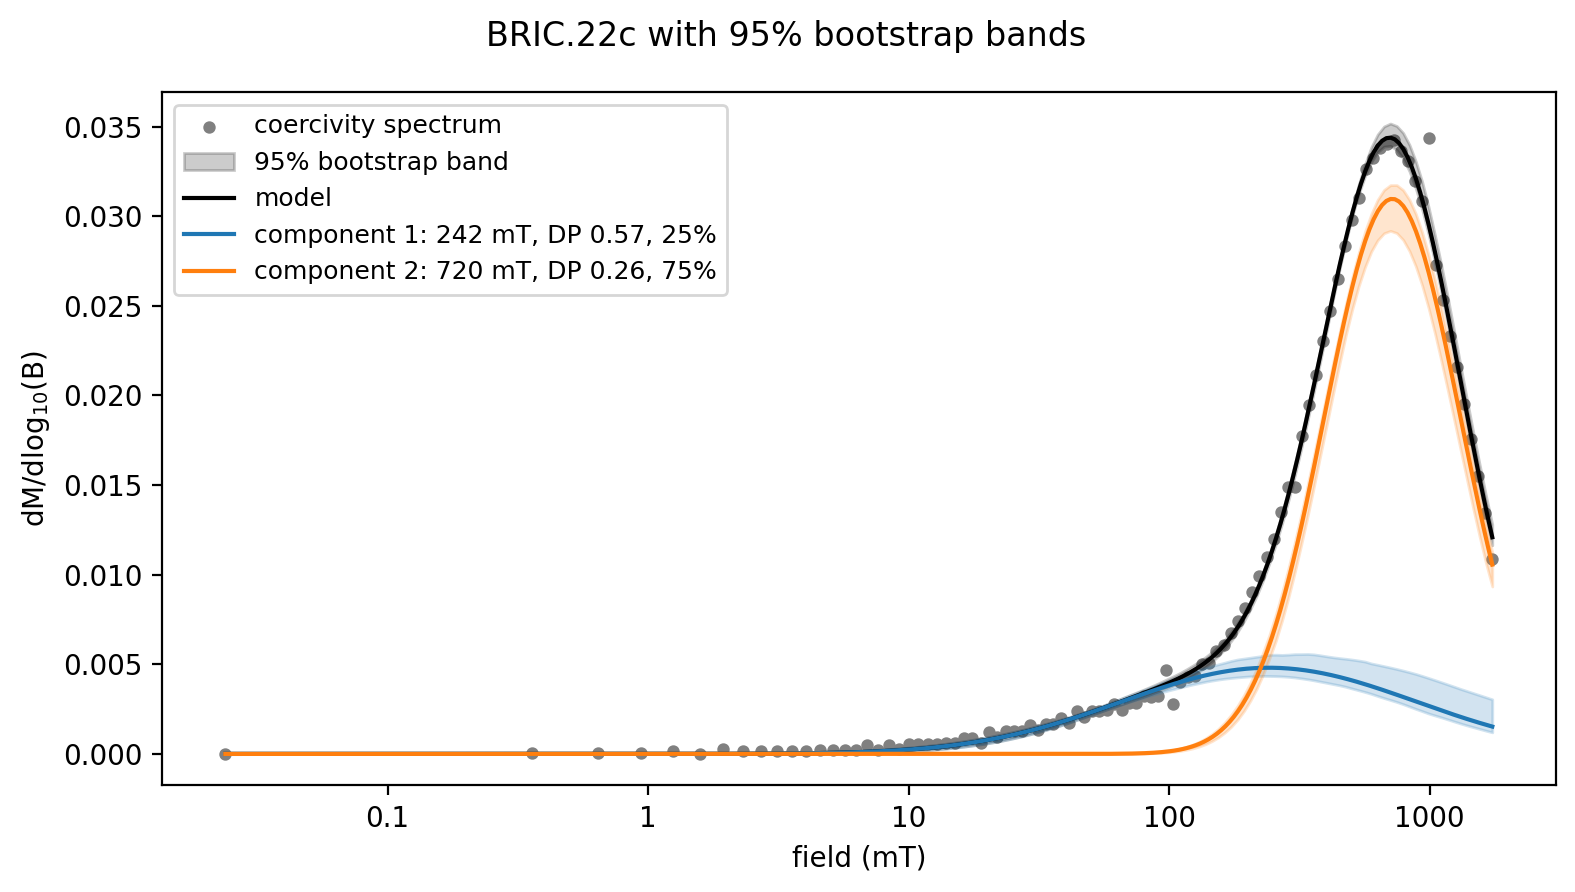

In [15]:
result_boot = rmag.unmixing_bootstrap(result_spectrum, n_boot=500,
                                      resample='cases', random_seed=42)
fig, axes = rmag.plot_coercivity_unmixing(result_boot,
                                          title=f'{specimen_name} with 95% bootstrap bands')

In [16]:
summary_columns = ['B_mean_mT_mean', 'B_mean_mT_p2_5', 'B_mean_mT_p97_5',
                   'sd_log_mean', 'sd_log_std',
                   'proportion_mean', 'proportion_p2_5', 'proportion_p97_5']
result_boot['bootstrap']['param_summary'][summary_columns].round(3)

,B_mean_mT_mean,B_mean_mT_p2_5,B_mean_mT_p97_5,sd_log_mean,sd_log_std,proportion_mean,proportion_p2_5,proportion_p97_5
component,,,,,,,,
1,257.00,220.310,352.575,0.576,0.037,0.261,0.233,0.317
2,723.27,706.624,735.432,0.262,0.034,0.739,0.683,0.767


## Validation against saved MAX UnMix results

Backfield curves for four of the red bed specimens, together with the two-component results saved from the MAX UnMix Shiny app (`Bh` and `DP` in $\log_{10}$ units and the observed contribution `OC` of each component), are included in the `example_data` folder. We fit each curve with symmetric components seeded automatically and compare against the MAX UnMix output. Exact agreement is not expected — MAX UnMix fits skewed components with a different skew parameterization, its `Bh` is a distribution location rather than a mean, and its input files were trimmed slightly differently — but the recovered component structure should be consistent.

In [17]:
bric_specimens = ['BRIC_20c', 'BRIC_22c', 'BRIC_26c', 'BRIC_31c']
validation_rows = []
for bric in bric_specimens:
    data = pd.read_csv(f'../example_data/backfield_unmixing/{bric}_backfield.csv')
    data.columns = ['B_mT', 'M']
    maxunmix_saved = pd.read_csv(
        f'../example_data/backfield_unmixing/{bric}_MaxUnMix_results_log.csv',
        index_col=0)
    x_bric = np.log10(data['B_mT'].to_numpy())
    M_bric = data['M'].to_numpy() - data['M'].min()
    fit = rmag.unmix_coercivity(x_bric, M_bric, method='maxunmix',
                                n_components=2, vary_skew=False,
                                n_boot=100, random_seed=3)
    summary = fit['bootstrap']['param_summary']
    for component in (1, 2):
        column = f'component {component}'
        validation_rows.append({
            'specimen': bric,
            'component': component,
            'rockmagpy B_mean (mT)': fit['params'].loc[component, 'B_mean_mT'],
            'MaxUnMix Bh (mT)': 10 ** maxunmix_saved.loc['Bh', column],
            'rockmagpy DP': fit['params'].loc[component, 'sd_log'],
            'MaxUnMix DP': maxunmix_saved.loc['DP', column],
            'rockmagpy proportion': fit['params'].loc[component, 'proportion'],
            'MaxUnMix OC': maxunmix_saved.loc['OC.mean', column],
            'proportion 95% CI': (round(summary.loc[component, 'proportion_p2_5'], 2),
                                  round(summary.loc[component, 'proportion_p97_5'], 2)),
        })
validation = pd.DataFrame(validation_rows).set_index(['specimen', 'component'])
validation.round(2)

rockmagpy B_mean (mT)  MaxUnMix Bh (mT)  rockmagpy DP  \
specimen component                                                          
BRIC_20c 1                         237.96            450.44          0.66   
         2                         832.29            751.38          0.28   
BRIC_22c 1                         240.10            339.44          0.56   
         2                         719.68            680.28          0.26   
BRIC_26c 1                         250.92            538.78          0.60   
         2                         738.79            690.47          0.26   
BRIC_31c 1                         223.28            240.28          0.60   
         2                         739.98            699.47          0.27   

                    MaxUnMix DP  rockmagpy proportion  MaxUnMix OC  \
specimen component                                                   
BRIC_20c 1                 0.92                  0.36         0.34   
         2                 0.28                  0.64         0.66   
BRIC_22c 1                 0.73                  0.25         0.25   
         2                 0.26                  0.75         0.75   
BRIC_26c 1                 0.87                  0.27         0.28   
         2                 0.26                  0.73         0.72   
BRIC_31c 1                 0.69                  0.28         0.28   
         2                 0.27                  0.72         0.72   

                   proportion 95% CI  
specimen component                    
BRIC_20c 1              (0.35, 0.37)  
         2              (0.63, 0.65)  
BRIC_22c 1              (0.25, 0.26)  
         2              (0.74, 0.75)  
BRIC_26c 1              (0.26, 0.28)  
         2              (0.72, 0.74)  
BRIC_31c 1              (0.28, 0.29)  
         2              (0.71, 0.72)

The symmetric two-component fits recover the same structure as MAX UnMix: a broad lower-coercivity component carrying roughly a quarter to a third of the remanence and a narrow component near 700–830 mT carrying the rest, with dispersions closely matching the saved `DP` values for the narrow component. The largest differences are in the broad component of specimens where the saved MAX UnMix models used strong skew (e.g., BRIC_20c, `S` = 1.35): a strongly skewed broad component and a symmetric broad component at lower field describe these spectra almost equally well. This kind of trade-off is inherent to coercivity unmixing and is why consistent initialization across a specimen suite — and reporting uncertainty — matter more than any single best-fit number.

## Sensitivity to initial parameter choices

Coercivity unmixing is a non-convex optimization problem: differently initialized fits can converge to different local minima that describe the data almost equally well, particularly when skew is allowed to vary. The cell below fits the BRIC.20c spectrum twice with skewed components — once seeded by automatic peak detection and once seeded near the solution published from the MAX UnMix program — and compares the outcomes.

In [18]:
experiment_20c = backfield_measurements[
    backfield_measurements['experiment'] == 'IRM-VSM2-LP-BCR-BF-198106'].reset_index(drop=True)
experiment_20c, Bcr_20c = rmag.process_backfield_data(experiment_20c,
                                                         smooth_mode='spline',
                                                         smooth_frac=0.0)
x_20c = experiment_20c['log_dc_field'].to_numpy()
M_20c = experiment_20c['magn_mass_shift'].to_numpy()

fit_a = rmag.unmix_coercivity(x_20c, M_20c, method='spectrum',
                              n_components=2, vary_skew=True)

x_mid, spectrum_20c = rmag.coercivity_spectrum_from_curve(x_20c, M_20c)
total_area = np.trapezoid(spectrum_20c, x_mid)
maxunmix_style_initial = pd.DataFrame({
    'contribution': [0.34 * total_area, 0.66 * total_area],
    'location': [np.log10(450), np.log10(750)],
    'dp': [0.9, 0.28],
    'skew': [0.0, 0.0]})
fit_b = rmag.unmix_coercivity(x_20c, M_20c, method='spectrum',
                              initial_parameters=maxunmix_style_initial,
                              vary_skew=True)

initialization_comparison = pd.DataFrame({
    'auto-seeded: B_mean (mT)': fit_a['params']['B_mean_mT'].round(0),
    'auto-seeded: proportion': fit_a['params']['proportion'].round(2),
    'MaxUnMix-seeded: B_mean (mT)': fit_b['params']['B_mean_mT'].round(0),
    'MaxUnMix-seeded: proportion': fit_b['params']['proportion'].round(2),
})
print(f"auto-seeded R^2 = {fit_a['stats']['r_squared']:.5f}, "
      f"MaxUnMix-seeded R^2 = {fit_b['stats']['r_squared']:.5f}")
initialization_comparison

auto-seeded R^2 = 0.99717, MaxUnMix-seeded R^2 = 0.99708


,auto-seeded: B_mean (mT),auto-seeded: proportion,MaxUnMix-seeded: B_mean (mT),MaxUnMix-seeded: proportion
component,,,,
1,55.0,0.14,219.0,0.42
2,683.0,0.86,939.0,0.58


Both fits describe the spectrum nearly equally well, yet they partition the remanence differently — a reminder that with skewed components the decomposition is not unique.

## Assessing uncertainty and non-uniqueness

The bootstrap intervals above measure *repeatability under measurement noise*, but they are conditional on the single solution the optimizer found — they do not reveal whether a genuinely different decomposition would fit comparably well, and they cannot incorporate mineralogical prior knowledge. Because coercivity unmixing is an ill-posed problem, quantifying this uncertainty is essential, and `rockmagpy` provides a dedicated toolkit for it:

- **`rmag.unmixing_multistart`** launches the fit from many initializations and reports the *distinct* solutions the spectrum admits, with their statistical weights;
- **`method='bayes'`** samples the full posterior with nested sampling, giving the complete uncertainty representation and the Bayesian evidence for choosing the number of components;
- **`rmag.mineral_priors`** constrains the decomposition with a library of characteristic mineral coercivity ranges;
- **`rmag.plot_unmixing_posterior`**, **`plot_unmixing_ensemble`**, and **`plot_unmixing_tradeoff`** visualize the uncertainty.

These methods, and the practical guidance for using them, are documented in depth in the companion notebook [`coercivity_unmixing_bayesian.ipynb`](./coercivity_unmixing_bayesian.ipynb), which also covers extending the framework with custom methods.

## Batch processing

If a suite of specimens has similar components (both in terms of number of components and their mean/dispersion) then the same initial parameters (or the same automatic seeding strategy) can be used for all of them. `rmag.unmix_backfield_experiments` processes every `LP-BCR-BF` experiment in a measurements table: data preparation, fitting with any registered method, optional resampling uncertainties, and collection of the results into a tidy components table (one row per experiment and component). A common initial-parameter table — or a per-experiment dictionary of tables, e.g. assembled with the interactive widget — can be supplied through the `initial_parameters` argument.

In [19]:
components_df, results = rmag.unmix_backfield_experiments(
    measurements, n_components=2, method='maxunmix', vary_skew=False,
    random_seed=42)

  IRM-VSM2-LP-BCR-BF-198106 (BRIC.20c): 240 mT (36%), 832 mT (64%), R^2 = 0.9961


  IRM-VSM2-LP-BCR-BF-198107 (BRIC.20c): 240 mT (36%), 832 mT (64%), R^2 = 0.9961


  IRM-VSM2-LP-BCR-BF-198073 (BRIC.31c): 223 mT (29%), 738 mT (71%), R^2 = 0.9874


  IRM-VSM2-LP-BCR-BF-198074 (BRIC.31c): 224 mT (28%), 740 mT (72%), R^2 = 0.9969


  IRM-VSM2-LP-BCR-BF-198193 (BRIC.22c): 242 mT (25%), 720 mT (75%), R^2 = 0.9973


  IRM-VSM2-LP-BCR-BF-198199 (BRIC.26c): 249 mT (27%), 739 mT (73%), R^2 = 0.9971


In [20]:
components_df[['experiment', 'specimen', 'component', 'B_mean_mT',
               'B_mean_mT_p2_5', 'B_mean_mT_p97_5', 'sd_log', 'proportion',
               'proportion_std', 'r_squared', 'Bcr_mT']].round(3)

,experiment,specimen,component,B_mean_mT,B_mean_mT_p2_5,B_mean_mT_p97_5,sd_log,proportion,proportion_std,r_squared,Bcr_mT
0,IRM-VSM2-LP-BCR-BF-198106,BRIC.20c,1,239.966,232.827,247.868,0.661,0.360,0.003,0.996,578.692
1,IRM-VSM2-LP-BCR-BF-198106,BRIC.20c,2,832.141,828.849,834.219,0.276,0.640,0.003,0.996,578.692
2,IRM-VSM2-LP-BCR-BF-198107,BRIC.20c,1,239.966,233.599,250.947,0.661,0.360,0.003,0.996,578.692
3,IRM-VSM2-LP-BCR-BF-198107,BRIC.20c,2,832.141,828.906,834.553,0.276,0.640,0.003,0.996,578.692
4,IRM-VSM2-LP-BCR-BF-198073,BRIC.31c,1,222.796,220.182,229.442,0.606,0.287,0.002,0.987,566.212
5,IRM-VSM2-LP-BCR-BF-198073,BRIC.31c,2,737.991,734.091,738.928,0.273,0.713,0.002,0.987,566.212
6,IRM-VSM2-LP-BCR-BF-198074,BRIC.31c,1,224.429,220.472,234.605,0.606,0.285,0.003,0.997,574.498
7,IRM-VSM2-LP-BCR-BF-198074,BRIC.31c,2,739.916,736.047,741.198,0.270,0.715,0.003,0.997,574.498
8,IRM-VSM2-LP-BCR-BF-198193,BRIC.22c,1,241.863,237.120,259.274,0.566,0.251,0.004,0.997,581.172
9,IRM-VSM2-LP-BCR-BF-198193,BRIC.22c,2,719.756,716.199,720.853,0.262,0.749,0.004,0.997,581.172


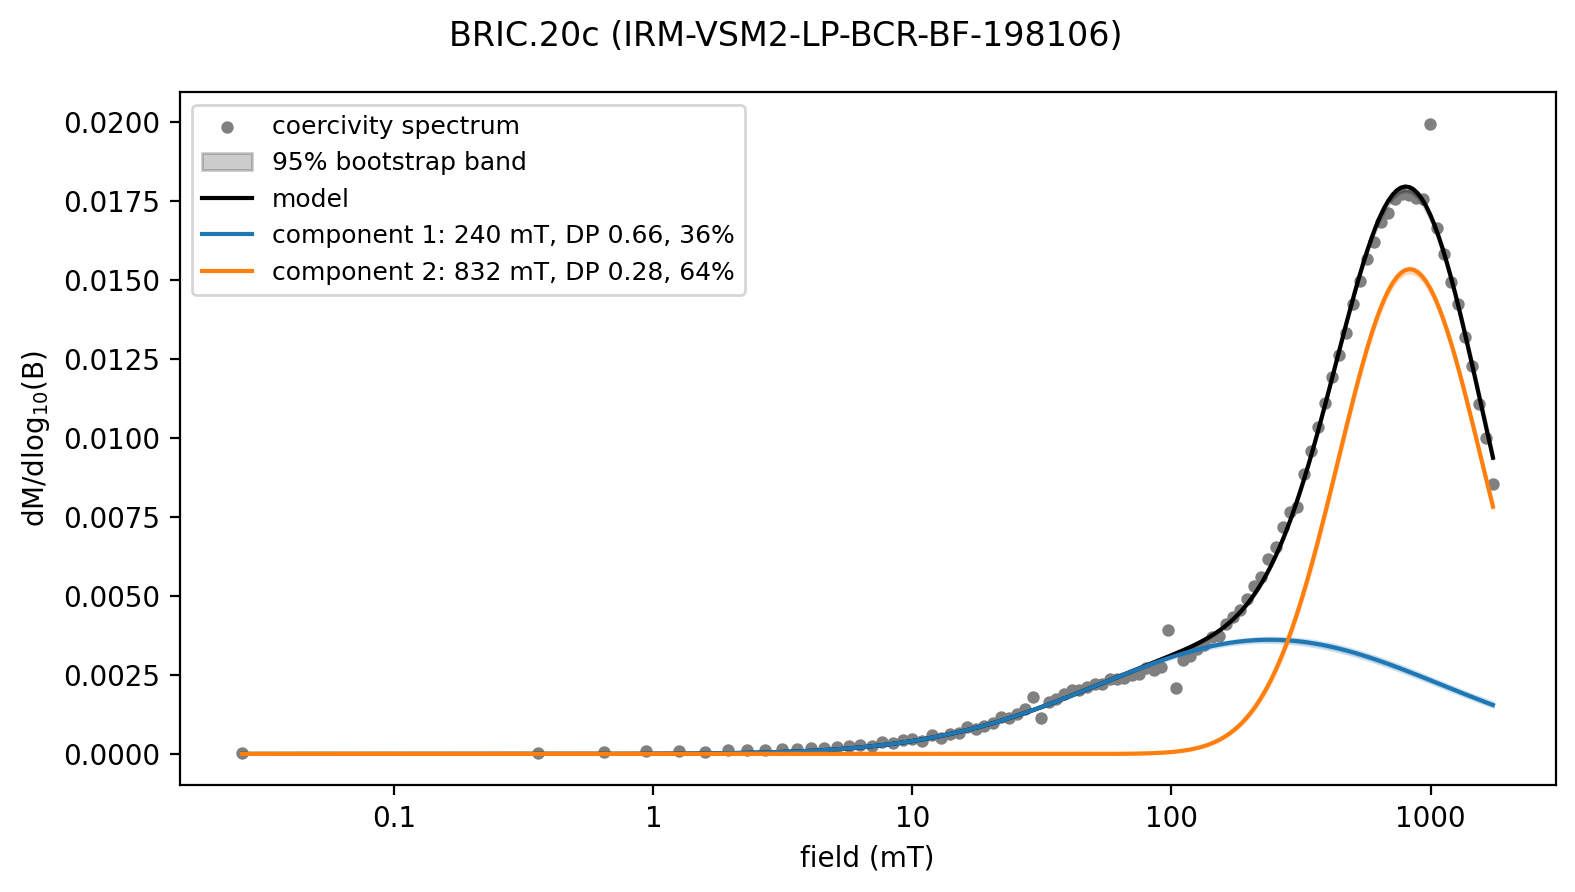

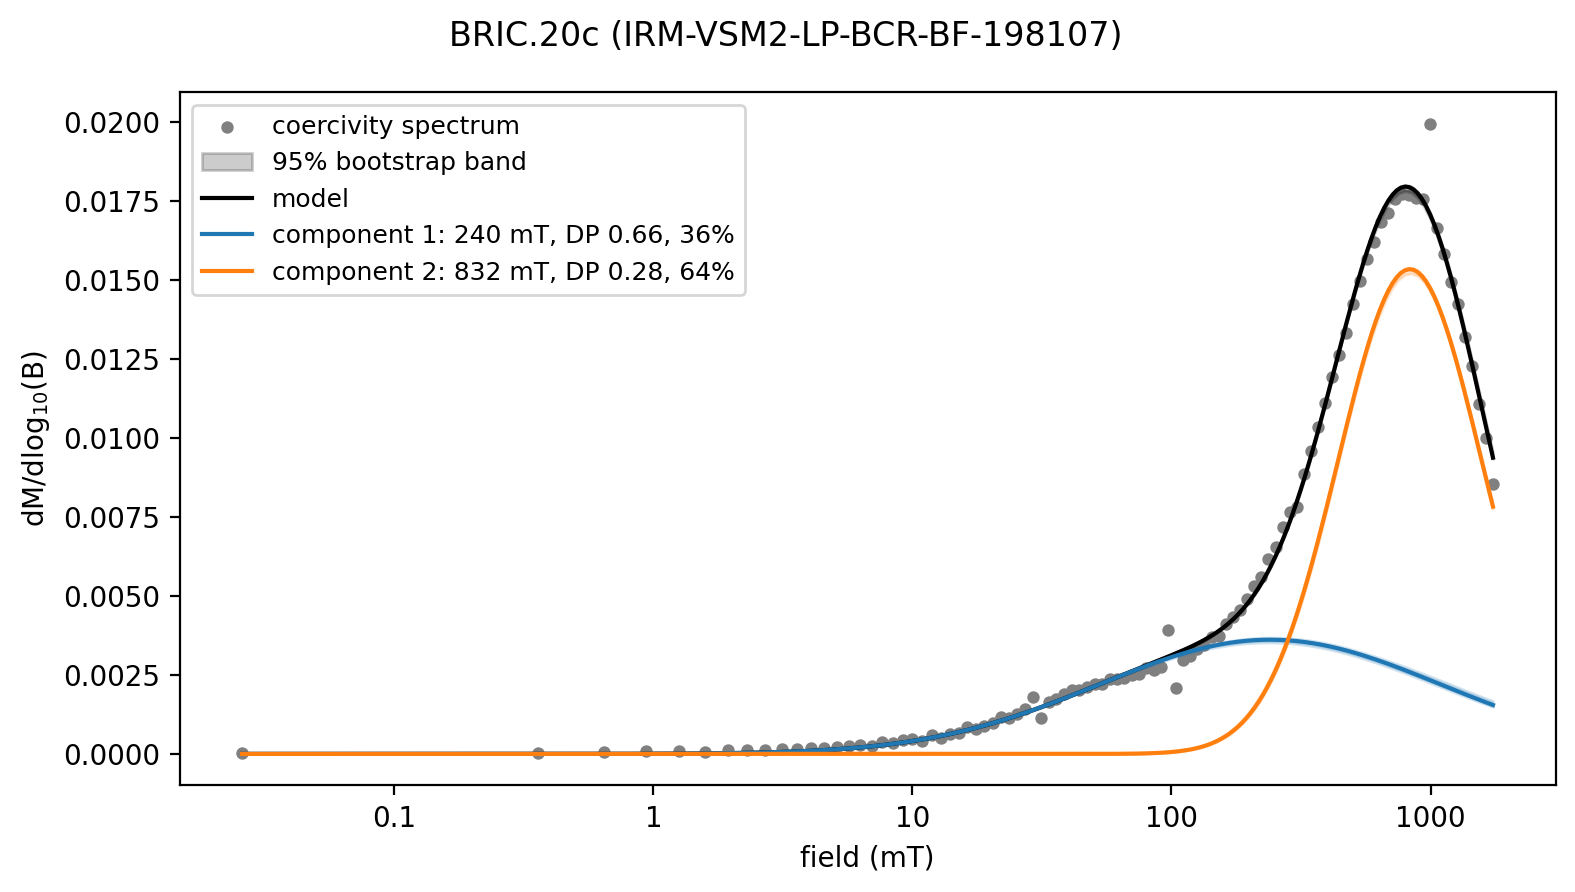

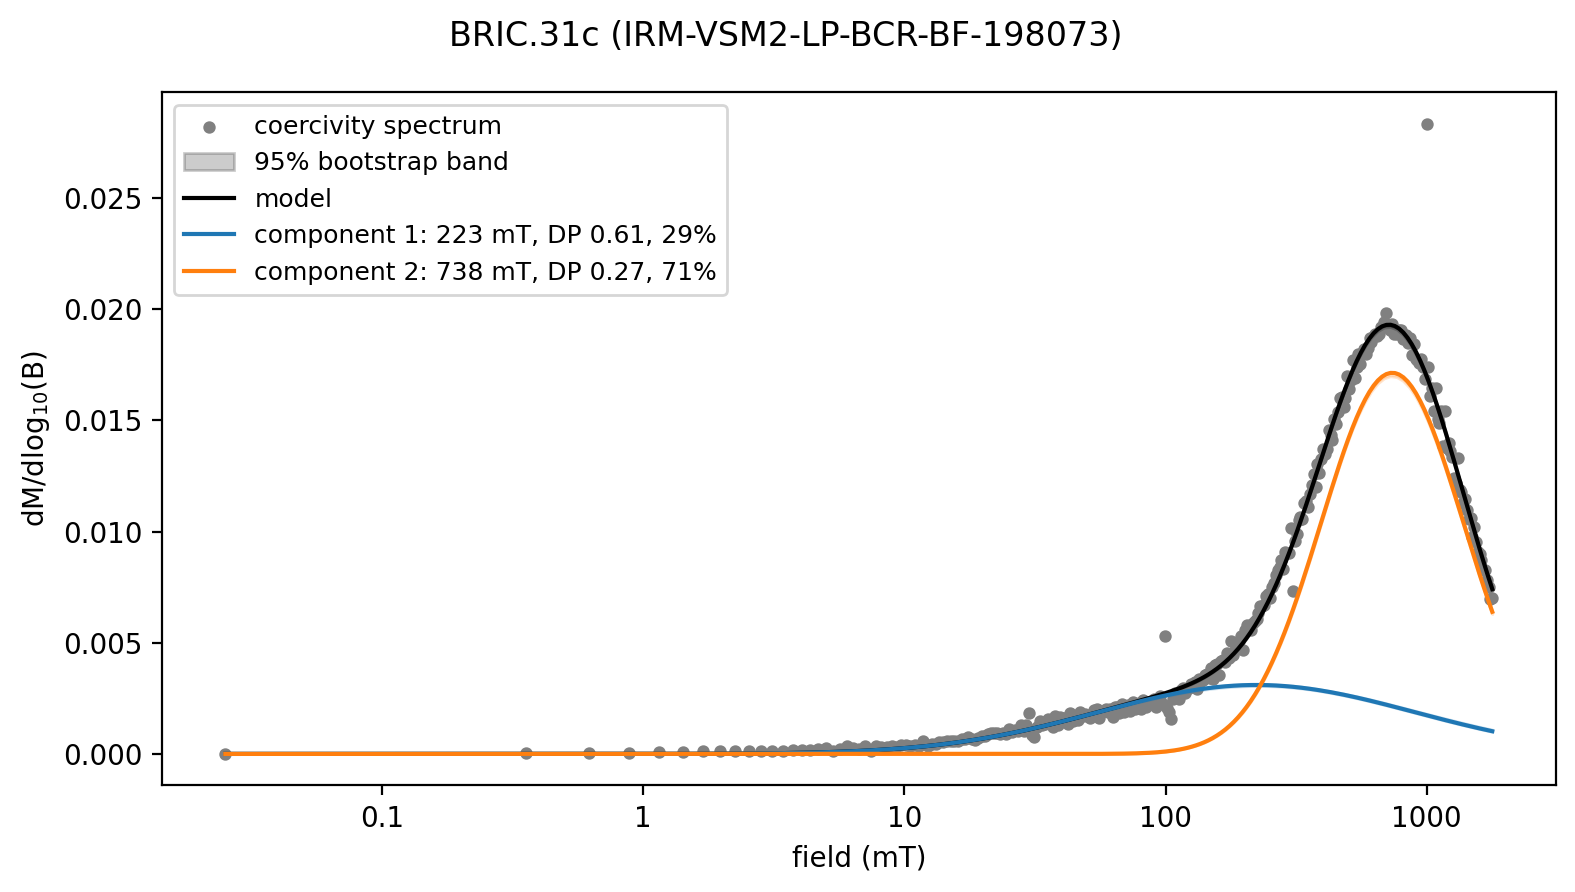

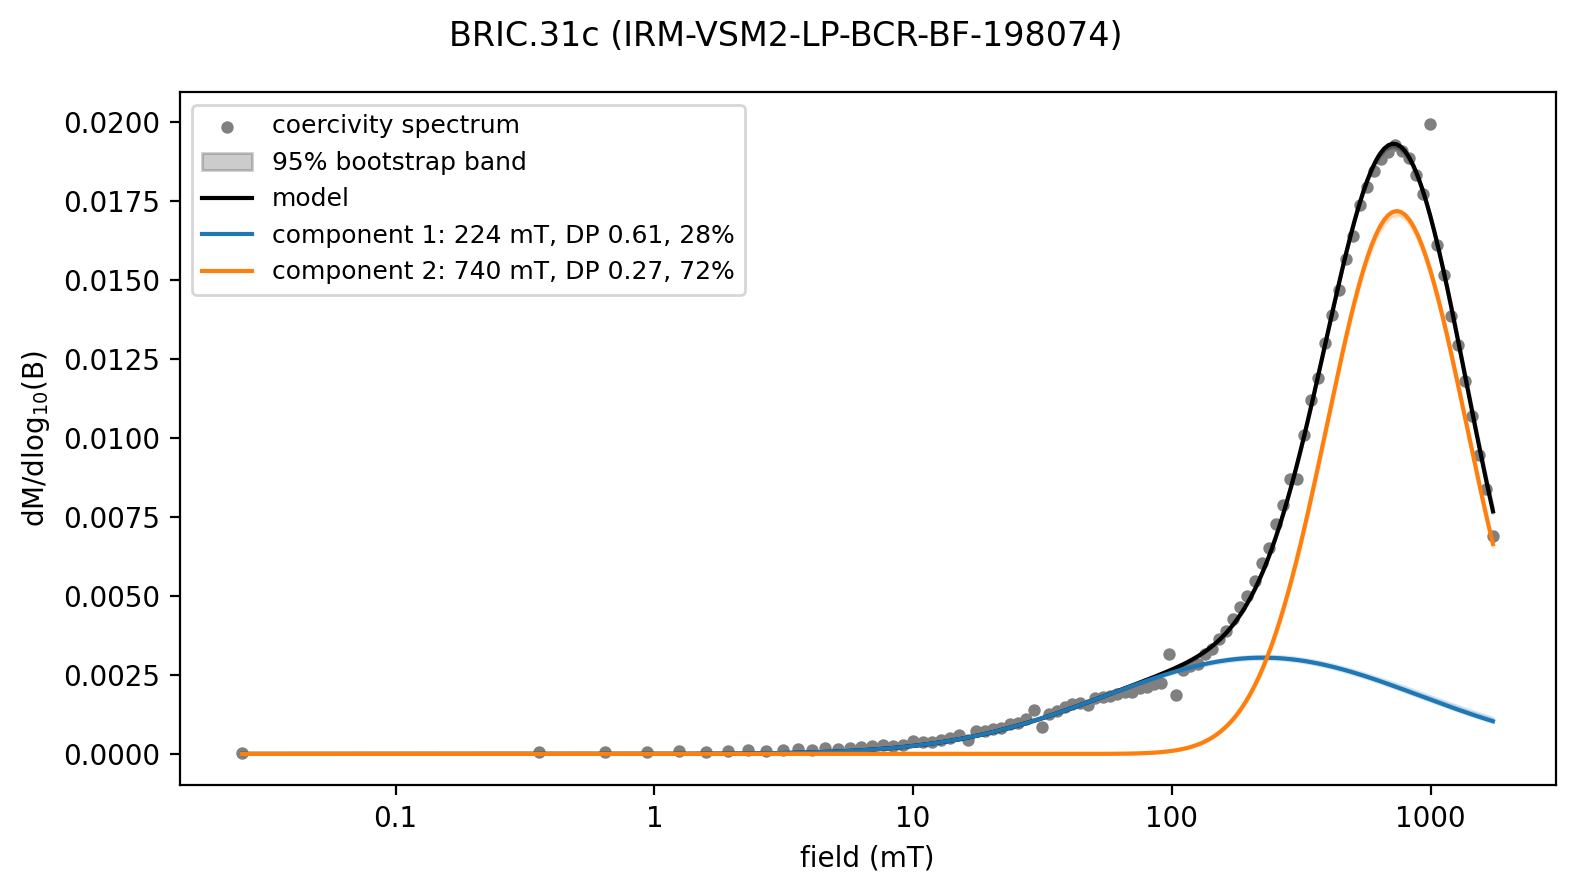

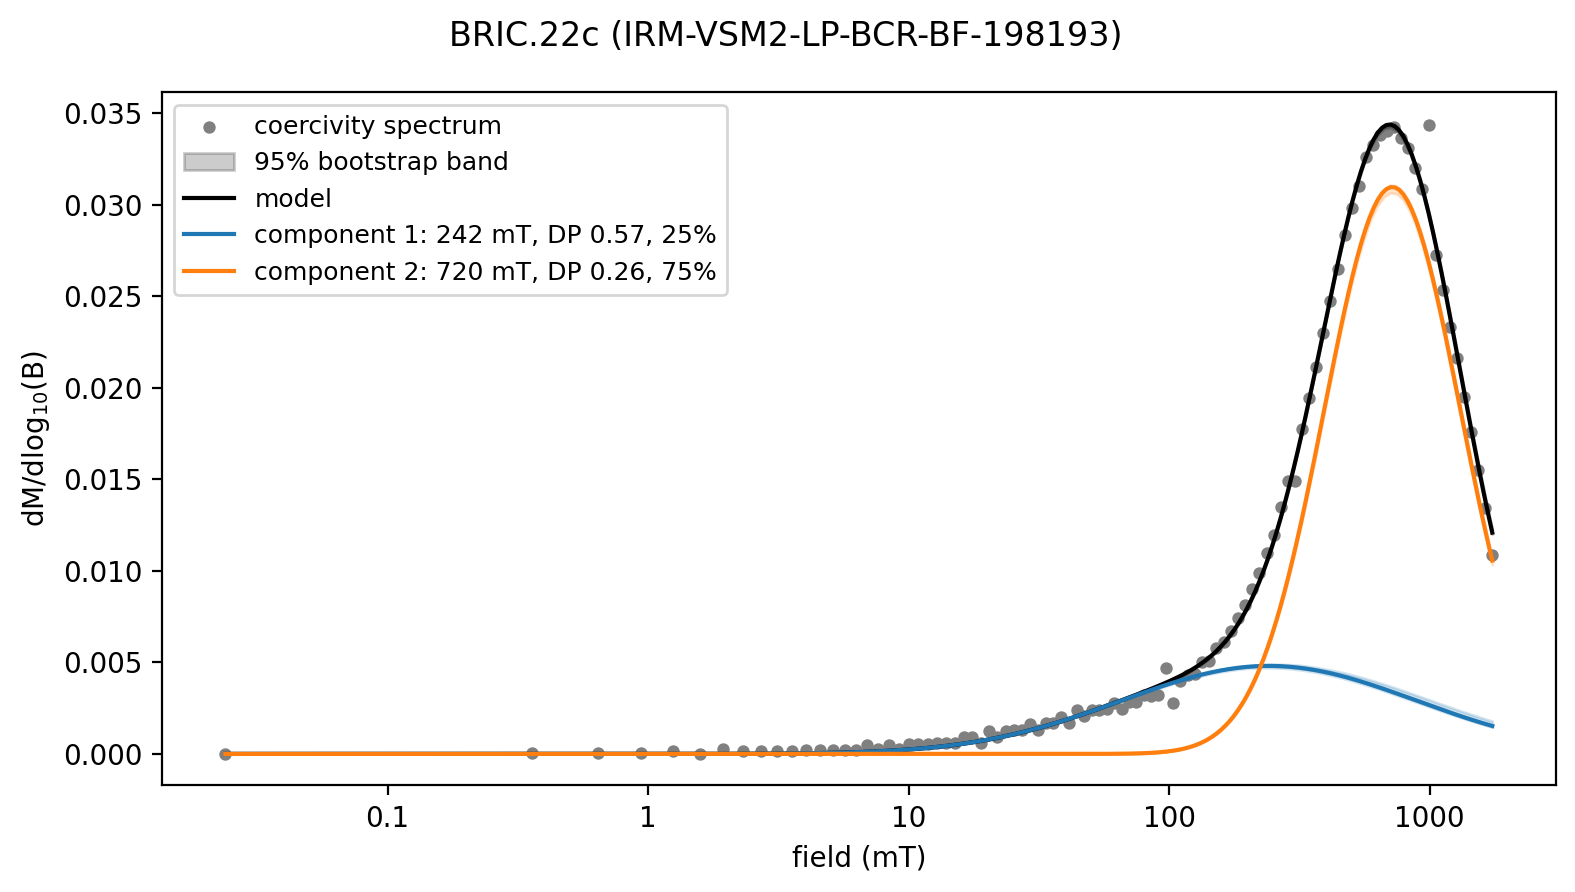

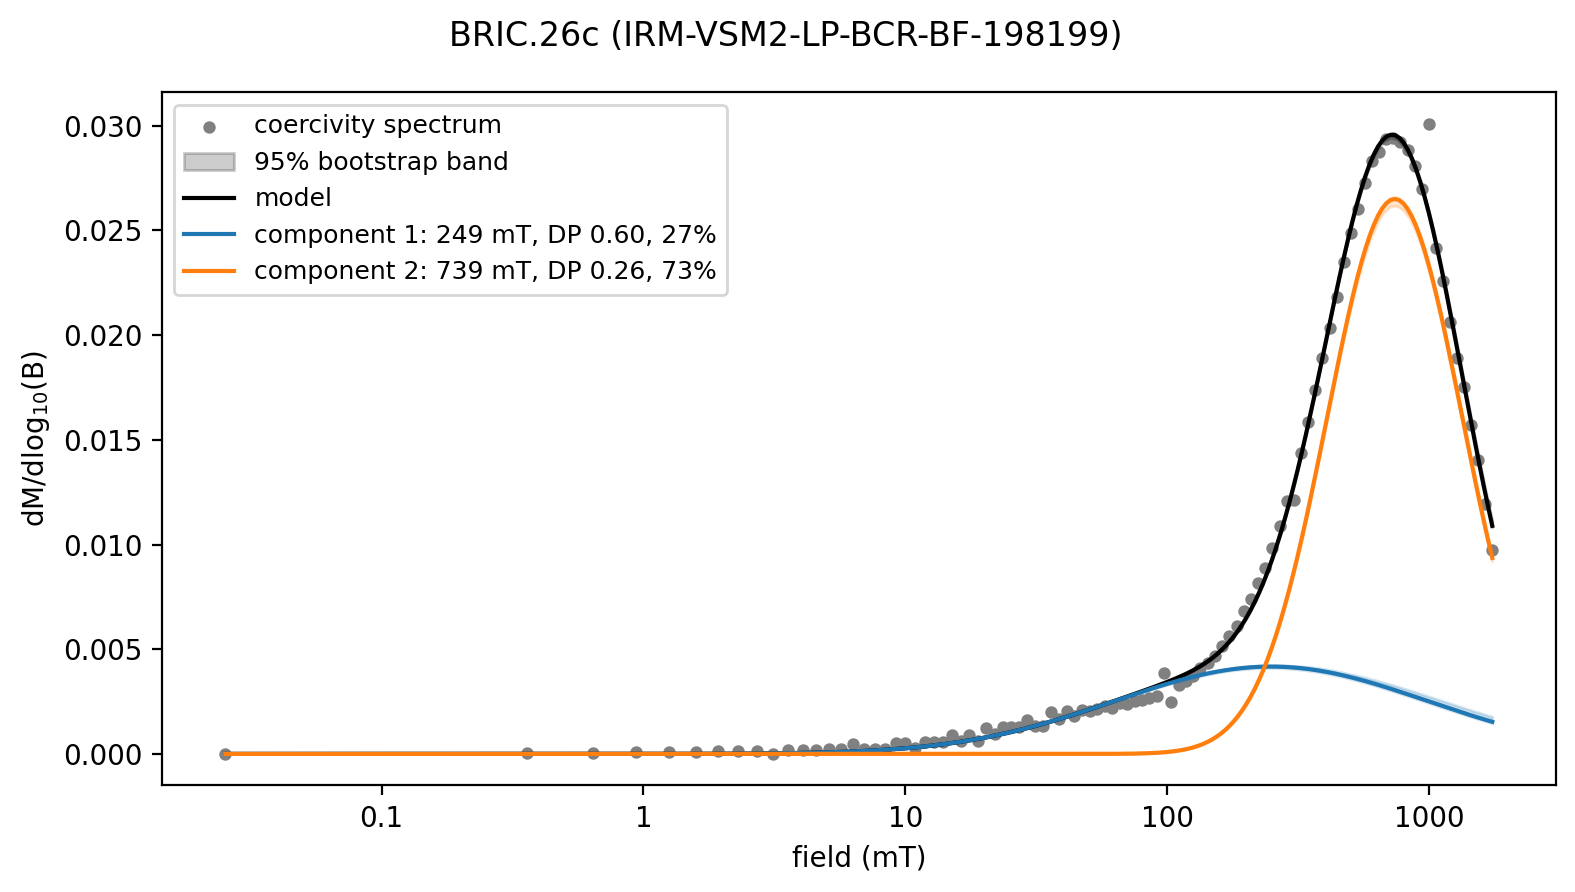

In [21]:
for batch_experiment, batch_result in results.items():
    batch_specimen = components_df.loc[
        components_df['experiment'] == batch_experiment, 'specimen'].iloc[0]
    fig, axes = rmag.plot_coercivity_unmixing(
        batch_result, title=f'{batch_specimen} ({batch_experiment})')
    plt.show()

## Recording results in the MagIC specimens table

`rmag.add_unmixing_to_specimens_table` records the unmixing results following the MagIC data model: with the default `mode='rows'`, one specimens row is added per component with the controlled-vocabulary columns `rem_cmf` (component median field, tesla), `rem_cd` (component dispersion, $\log_{10}$ units), and `rem_n_comp` (number of components), plus the complete parameter set (proportions, confidence intervals) as JSON in the `description` column. An alternative `mode='description'` leaves the table structure unchanged and stores the full model as JSON on the existing specimen rows (readable back with `rmag.parse_specimen_description`). The resulting table can be written out with `pmag.magic_write` for upload to MagIC.

In [22]:
specimens_updated = rmag.add_unmixing_to_specimens_table(specimens, components_df,
                                                     mode='rows')
component_rows = specimens_updated[specimens_updated['rem_cmf'].notna()]
component_rows[['specimen', 'experiments', 'method_codes',
                'rem_cmf', 'rem_cd', 'rem_n_comp']].round(4)

,specimen,experiments,method_codes,rem_cmf,rem_cd,rem_n_comp
14,BRIC.31c,IRM-VSM2-LP-BCR-BF-198073,LP-BCR-BF,0.2228,0.6059,2.0
15,BRIC.31c,IRM-VSM2-LP-BCR-BF-198073,LP-BCR-BF,0.7380,0.2726,2.0
16,BRIC.31c,IRM-VSM2-LP-BCR-BF-198074,LP-BCR-BF,0.2244,0.6058,2.0
17,BRIC.31c,IRM-VSM2-LP-BCR-BF-198074,LP-BCR-BF,0.7399,0.2697,2.0
18,BRIC.20c,IRM-VSM2-LP-BCR-BF-198106,LP-BCR-BF,0.2400,0.6611,2.0
19,BRIC.20c,IRM-VSM2-LP-BCR-BF-198106,LP-BCR-BF,0.8321,0.2765,2.0
20,BRIC.20c,IRM-VSM2-LP-BCR-BF-198107,LP-BCR-BF,0.2400,0.6611,2.0
21,BRIC.20c,IRM-VSM2-LP-BCR-BF-198107,LP-BCR-BF,0.8321,0.2765,2.0
22,BRIC.22c,IRM-VSM2-LP-BCR-BF-198193,LP-BCR-BF,0.2419,0.5659,2.0
23,BRIC.22c,IRM-VSM2-LP-BCR-BF-198193,LP-BCR-BF,0.7198,0.2616,2.0


## Next steps

For rigorous uncertainty quantification — mapping non-unique solutions, sampling the full Bayesian posterior, constraining the fit with mineralogical priors, and visualizing all of it — see the companion notebook [`coercivity_unmixing_bayesian.ipynb`](./coercivity_unmixing_bayesian.ipynb). It also shows how to register custom unmixing methods with `rmag.register_unmixing_method`.

## References

Egli, R. (2003). Analysis of the field dependence of remanent magnetization curves. *Journal of Geophysical Research*, 108, 2081.

Heslop, D., Dekkers, M. J., Kruiver, P. P., & van Oorschot, I. H. M. (2002). Analysis of isothermal remanent magnetization acquisition curves using the expectation-maximization algorithm. *Geophysical Journal International*, 148, 58–64.

Heslop, D. (2015). Numerical strategies for magnetic mineral unmixing. *Earth-Science Reviews*, 150, 256–284. https://doi.org/10.1016/j.earscirev.2015.07.007

Kruiver, P. P., Dekkers, M. J., & Heslop, D. (2001). Quantification of magnetic coercivity components by the analysis of acquisition curves of isothermal remanent magnetisation. *Earth and Planetary Science Letters*, 189, 269–276.

Maxbauer, D. P., Feinberg, J. M., & Fox, D. L. (2016). MAX UnMix: A web application for unmixing magnetic coercivity distributions. *Computers & Geosciences*, 95, 140–145. https://doi.org/10.1016/j.cageo.2016.07.009

Robertson, D. J., & France, D. E. (1994). Discrimination of remanence-carrying minerals in mixtures, using isothermal remanent magnetisation acquisition curves. *Physics of the Earth and Planetary Interiors*, 82, 223–234.

Swanson-Hysell, N. L., Fairchild, L. M., & Slotznick, S. P. (2019). Primary and secondary red bed magnetization constrained by fluvial intraclasts. *Journal of Geophysical Research: Solid Earth*, 124. https://doi.org/10.1029/2018JB017067